# Results of the tutorial exercises

Worked solutions of the two exercises at the end of `tutorial_nuosc.ipynb`, for **T2K, Hyper-K, NOvA and DUNE**.
Only oscillation probabilities are used (no fluxes, no event rates).

1. **Exercise 1:** vacuum vs matter at the four experiments: (a) probabilities vs energy, (b) size of the matter
   effect at the typical energy, (c) what happens in vacuum.
2. **Exercise 2:** the dependence of $P(\nu_\mu\to\nu_e)$ and $P(\nu_\mu\to\nu_\mu)$ on $\delta_{CP}$, in vacuum and matter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nuosc import NeutrinoOscillator, get_experiment, K_MATTER
from nuosc.plotting import set_style

SET_STYLE = True     # True: nuosc style (latex_style -> SciencePlots -> default); False: keep your own matplotlib settings
c = set_style(SET_STYLE)   # list of colours used in the plots

EXPERIMENTS = ["T2K", "HyperK", "NOvA", "DUNE"]
ORDERINGS = ["NO", "IO"]

def label(a, b, anti=False):
    names = {"e": "e", "mu": r"\mu", "tau": r"\tau"}
    nu = r"\bar\nu" if anti else r"\nu"
    return rf"$P({nu}_{{{names[a]}}}\to{nu}_{{{names[b]}}})$"

for name in EXPERIMENTS:
    cfg = get_experiment(name)
    print(f"{name:7s} L = {cfg['baseline']:6.0f} km   rho = {cfg['rho']:.2f} g/cm^3   "
          f"E_typ = {cfg['E_peak']} GeV   L/E = {cfg['baseline'] / cfg['E_peak']:.0f} km/GeV")

plot style: latex_style
T2K     L =    295 km   rho = 2.60 g/cm^3   E_typ = 0.6 GeV   L/E = 492 km/GeV
HyperK  L =    295 km   rho = 2.60 g/cm^3   E_typ = 0.6 GeV   L/E = 492 km/GeV
NOvA    L =    810 km   rho = 2.84 g/cm^3   E_typ = 2.0 GeV   L/E = 405 km/GeV
DUNE    L =   1300 km   rho = 2.85 g/cm^3   E_typ = 2.5 GeV   L/E = 520 km/GeV


## Exercise 1: vacuum vs matter at the four experiments

### 1a. $P(\nu_\mu\to\nu_e)$ and $P(\nu_\mu\to\nu_\mu)$ vs energy

Top row: appearance, bottom row: disappearance. Solid: matter, dashed: vacuum. The dotted line marks the typical
energy of each experiment.

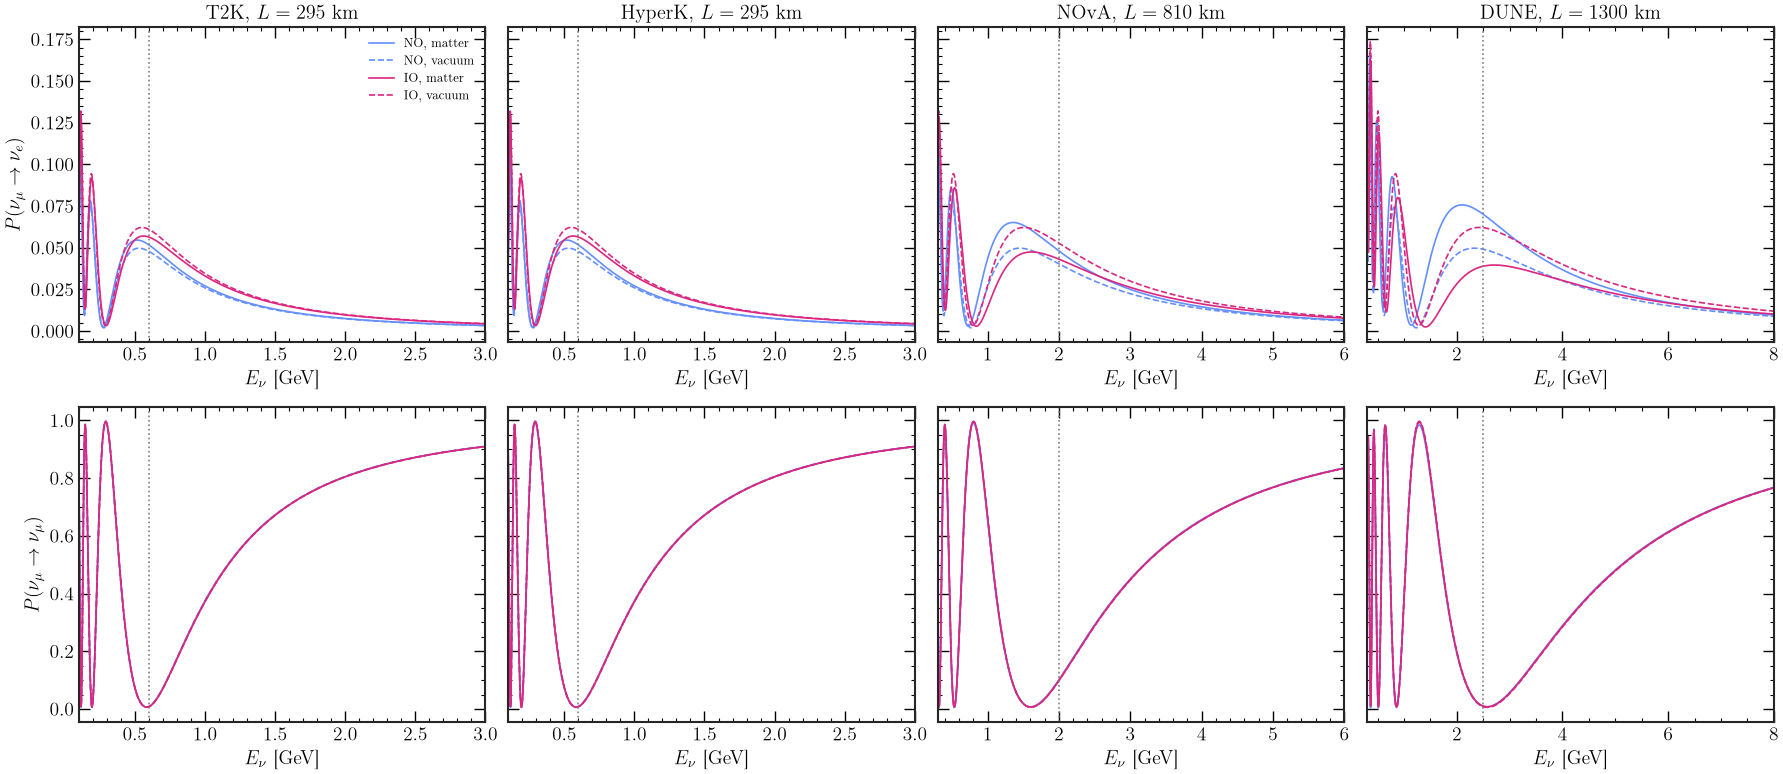

In [2]:
def plot_four(anti):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey="row")
    for j, name in enumerate(EXPERIMENTS):
        cfg = get_experiment(name)
        for row, (a, b) in enumerate([("mu", "e"), ("mu", "mu")]):
            ax = axes[row, j]
            for i, o in enumerate(ORDERINGS):
                osc = NeutrinoOscillator.from_experiment(name, ordering=o, antineutrino=anti)
                ax.plot(osc.energy, osc.matter(a, b), color=c[i], label=f"{o}, matter")
                ax.plot(osc.energy, osc.vacuum(a, b), color=c[i], ls="--", label=f"{o}, vacuum")
            ax.axvline(cfg["E_peak"], color="gray", ls=":")
            ax.set_xlim(*cfg["E_range"])
            ax.set_xlabel(r"$E_\nu$ [GeV]")
            if row == 0:
                ax.set_title(f"{name}, $L = {cfg['baseline']:.0f}$ km")
            if j == 0:
                ax.set_ylabel(label(a, b, anti))
    axes[0, 0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()

plot_four(anti=False)

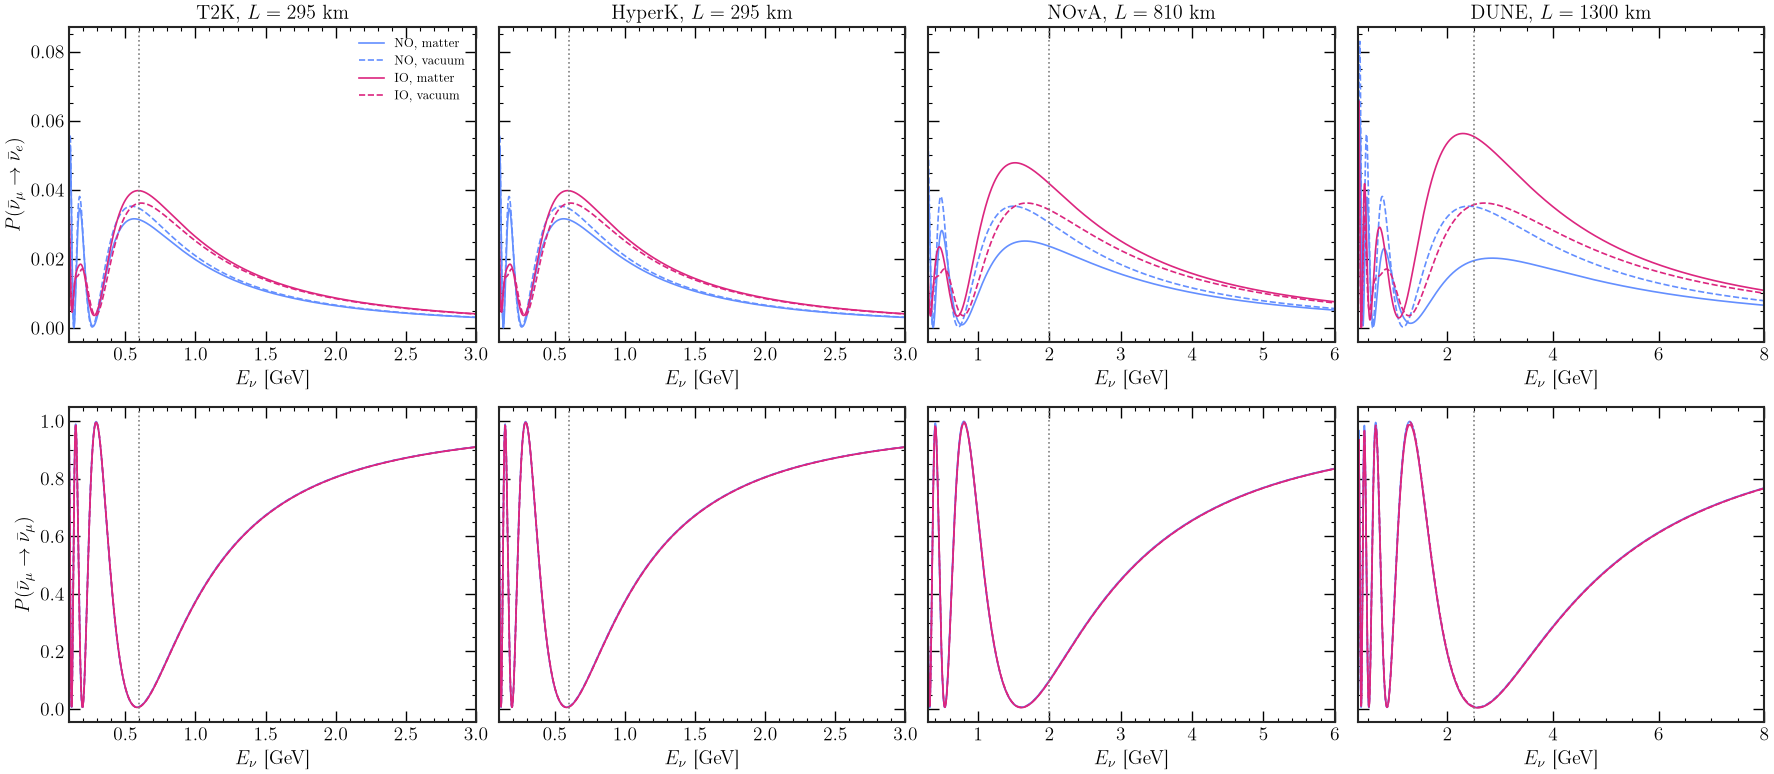

In [3]:
plot_four(anti=True)

### 1b. How big is the matter effect at the typical energy?

We fix $L$ and $\rho$ to each experiment and take its typical energy `E_peak`
(0.6 GeV for T2K/Hyper-K, 2.0 GeV for NOvA, 2.5 GeV for DUNE). These are close to the mean energy of the
appeared $\nu_e$ events (about 0.65, 1.9 and 2.8 GeV with the spectra in `far_detector_spectra/`).

#### The table

In [4]:
CHANNELS = [("mu", "e"), ("mu", "mu"), ("e", "e")]

rel = {}      # rel[(channel, anti, ordering)] = list over experiments of (P_mat - P_vac) / P_vac in %
print(f"{'exp':7s} {'ord':3s} {'beam':5s} {'channel':10s} {'P_vac':>8s} {'P_mat':>8s} {'diff':>8s}")
for name in EXPERIMENTS:
    E0 = get_experiment(name)["E_peak"]
    for o in ORDERINGS:
        for anti in [False, True]:
            osc = NeutrinoOscillator.from_experiment(name, ordering=o, antineutrino=anti)
            for a, b in CHANNELS:
                Pv = float(osc.vacuum(a, b, E=E0))
                Pm = float(osc.matter(a, b, E=E0))
                r = 100 * (Pm - Pv) / Pv
                rel.setdefault((a, b, anti, o), []).append(r)
                print(f"{name:7s} {o:3s} {'nubar' if anti else 'nu':5s} {a + '->' + b:10s} "
                      f"{Pv:8.4f} {Pm:8.4f} {r:+7.1f}%")
    print()

exp     ord beam  channel       P_vac    P_mat     diff
T2K     NO  nu    mu->e        0.0478   0.0517    +8.2%
T2K     NO  nu    mu->mu       0.0083   0.0085    +3.5%
T2K     NO  nu    e->e         0.9117   0.9039    -0.8%
T2K     NO  nubar mu->e        0.0346   0.0313    -9.4%
T2K     NO  nubar mu->mu       0.0083   0.0080    -3.3%
T2K     NO  nubar e->e         0.9117   0.9193    +0.8%
T2K     IO  nu    mu->e        0.0610   0.0564    -7.5%
T2K     IO  nu    mu->mu       0.0073   0.0076    +4.5%
T2K     IO  nu    e->e         0.9113   0.9187    +0.8%
T2K     IO  nubar mu->e        0.0361   0.0397   +10.0%
T2K     IO  nubar mu->mu       0.0073   0.0069    -4.3%
T2K     IO  nubar e->e         0.9113   0.9038    -0.8%

HyperK  NO  nu    mu->e        0.0478   0.0517    +8.2%
HyperK  NO  nu    mu->mu       0.0083   0.0085    +3.5%
HyperK  NO  nu    e->e         0.9117   0.9039    -0.8%
HyperK  NO  nubar mu->e        0.0346   0.0313    -9.4%
HyperK  NO  nubar mu->mu       0.0083   0.0080 

#### The plot

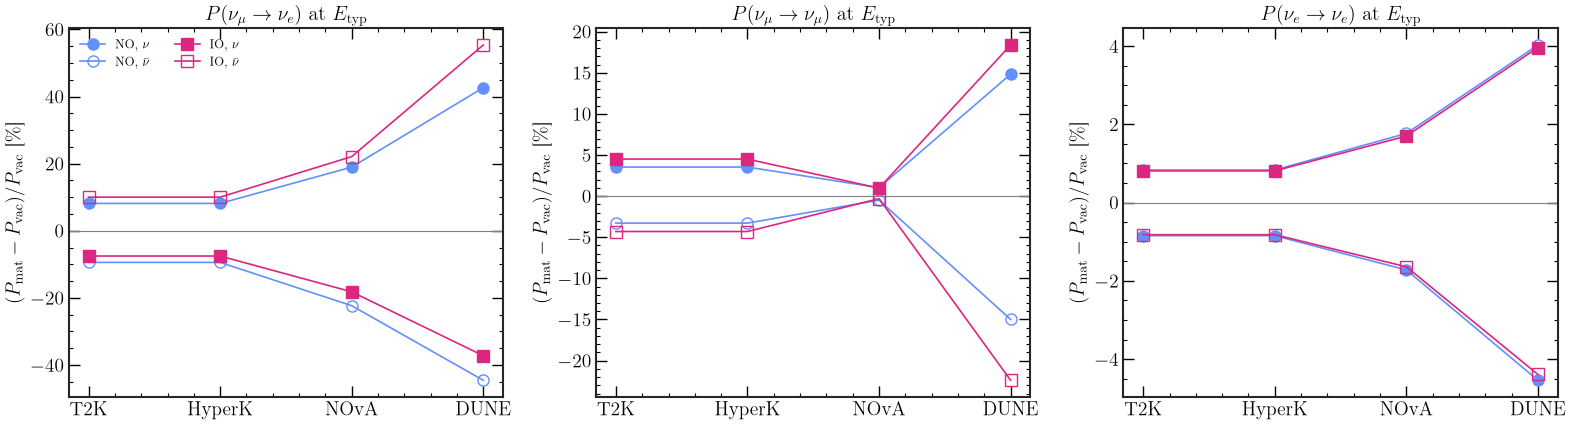

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(EXPERIMENTS))
styles = {("NO", False): dict(color=c[0], marker="o"), ("NO", True): dict(color=c[0], marker="o", mfc="none"),
          ("IO", False): dict(color=c[1], marker="s"), ("IO", True): dict(color=c[1], marker="s", mfc="none")}

for ax, (a, b) in zip(axes, CHANNELS):
    for (o, anti), st in styles.items():
        ax.plot(x, rel[(a, b, anti, o)], ls="-", ms=8, **st,
                label=f"{o}, " + (r"$\bar\nu$" if anti else r"$\nu$"))
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xticks(x, EXPERIMENTS)
    ax.set_ylabel(r"$(P_\mathrm{mat}-P_\mathrm{vac})/P_\mathrm{vac}$ [\%]")
    ax.set_title(label(a, b) + r" at $E_\mathrm{typ}$")
axes[0].legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

#### Why: the size of the matter term

The matter effect is controlled by the ratio of the matter potential $A = 2\sqrt2\,G_F N_e E$ to $\Delta m^2_{31}$
(and, at the oscillation maximum, $A L \propto \rho\,L$ since $E \propto L$ there):

In [6]:
for name in EXPERIMENTS:
    cfg = get_experiment(name)
    A = K_MATTER * 0.5 * cfg["rho"] * cfg["E_peak"]          # eV^2  (Ye = 0.5)
    print(f"{name:7s} A = {A:.2e} eV^2   A / dm2_31 = {A / 2.513e-3:.3f}")

T2K     A = 1.19e-04 eV^2   A / dm2_31 = 0.047
HyperK  A = 1.19e-04 eV^2   A / dm2_31 = 0.047
NOvA    A = 4.34e-04 eV^2   A / dm2_31 = 0.173
DUNE    A = 5.43e-04 eV^2   A / dm2_31 = 0.216


**What we learn**

* The effect grows with the baseline (at the oscillation maximum $E\propto L$, so $A/\Delta m^2_{31}\propto E$ grows
  too): about **8–10 %** on $P(\nu_\mu\to\nu_e)$ at T2K / Hyper-K, **~20 %** at NOvA, **~40–55 %** at DUNE.
  T2K and Hyper-K are identical (same $L$, same beam).
* For **$\nu$ in NO** matter **enhances** $P(\nu_\mu\to\nu_e)$; for $\bar\nu$ in NO it **suppresses** it.
  In IO the signs are reversed. This opposite sign for $\nu$ and $\bar\nu$ is what makes matter effects look like
  CP violation, and what lets long-baseline experiments (above all DUNE) measure the mass ordering.
* $P(\nu_\mu\to\nu_\mu)$ at the typical energy of T2K, Hyper-K and DUNE is close to its minimum (the oscillation
  dip, $P\approx 0.01$), so the *relative* change can look large (up to ~20 % at DUNE) but the *absolute* change is
  tiny ($\sim 10^{-3}$). For NOvA, $E_\mathrm{typ}=2$ GeV is a bit above the dip (1.6 GeV), $P\approx0.1$ and the change
  is ~1 %. The disappearance channel is almost insensitive to matter.
* $P(\nu_e\to\nu_e)$ changes by a few percent at most (4 % at DUNE).

### 1c. What happens in vacuum?

In vacuum the probability depends on $L$ and $E$ **only through $L/E$** (the phases are
$\Delta_{ij} = 1.267\,\Delta m^2_{ij}L/E$). Plotting the vacuum curves vs $L/E$, all experiments fall on the
same curve; in matter they do not, because the matter term depends on $E$ (and $\rho$) separately.

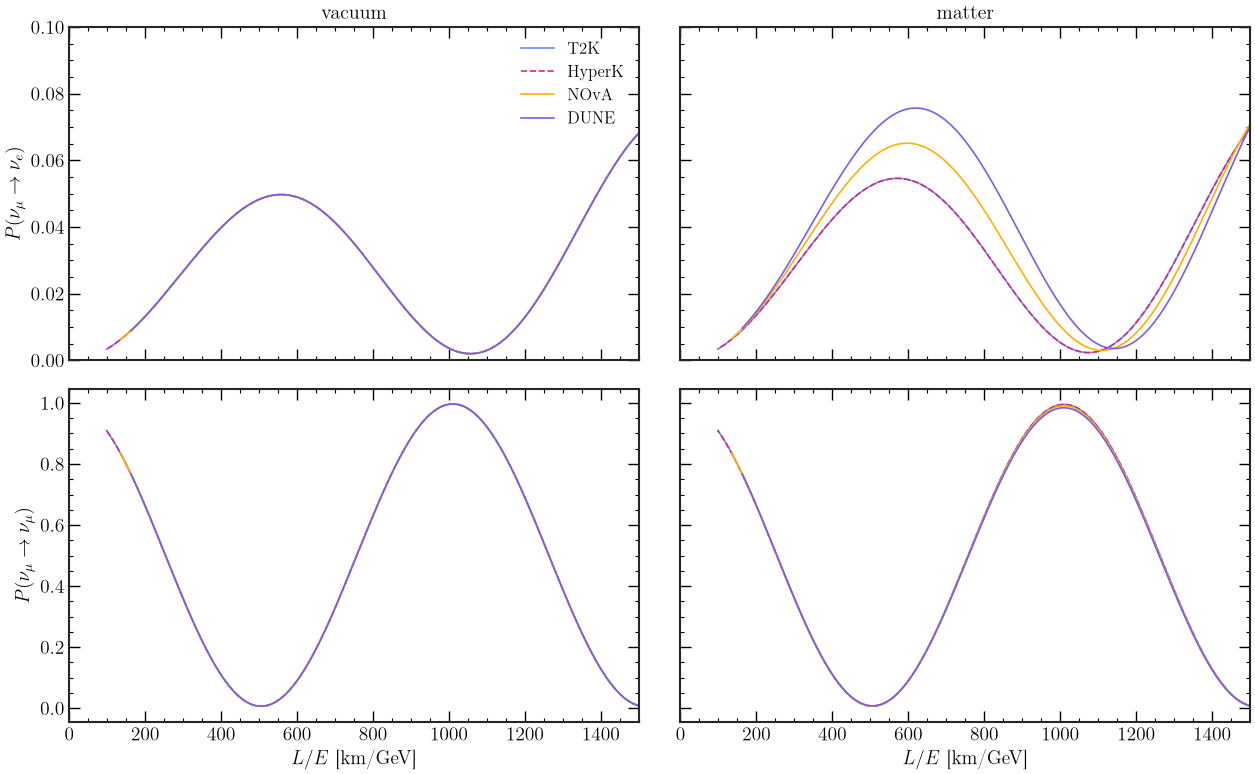

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")
for j, matter in enumerate([False, True]):
    for row, (a, b) in enumerate([("mu", "e"), ("mu", "mu")]):
        ax = axes[row, j]
        for i, name in enumerate(EXPERIMENTS):
            osc = NeutrinoOscillator.from_experiment(name)
            LE = osc.baseline / osc.energy
            P = osc.matter(a, b) if matter else osc.vacuum(a, b)
            ax.plot(LE, P, color=c[i], ls="--" if name == "HyperK" else "-", label=name)
        ax.set_xlim(0, 1500)
        if row == 0:
            ax.set_ylim(0, 0.1)
        if row == 0:
            ax.set_title("matter" if matter else "vacuum")
        if row == 1:
            ax.set_xlabel(r"$L/E$ [km/GeV]")
        if j == 0:
            ax.set_ylabel(label(a, b))
axes[0, 0].legend()
plt.tight_layout()
plt.show()

A quick numerical check: DUNE at 2.5 GeV and T2K at the same $L/E$ ($E = 2.5\times295/1300$ GeV).

In [8]:
dune = NeutrinoOscillator.from_experiment("DUNE")
t2k = NeutrinoOscillator.from_experiment("T2K")
E_t2k = 2.5 * t2k.baseline / dune.baseline
print(f"vacuum: DUNE {float(dune.vacuum('mu', 'e', E=2.5)):.5f}   T2K {float(t2k.vacuum('mu', 'e', E=E_t2k)):.5f}")
print(f"matter: DUNE {float(dune.matter('mu', 'e', E=2.5)):.5f}   T2K {float(t2k.matter('mu', 'e', E=E_t2k)):.5f}")

vacuum: DUNE 0.04910   T2K 0.04910
matter: DUNE 0.07005   T2K 0.05341


In vacuum it also follows that:

* **T2K and Hyper-K** are identical (same $L$, and in matter also the same $\rho$).
* All experiments are designed to sit near the **first oscillation maximum**,
  $L/E \approx 400$–$500$ km/GeV, so their vacuum probabilities at the typical energy are very similar
  ($P(\nu_\mu\to\nu_e)\approx 0.04$–$0.05$ for NO; $P(\nu_\mu\to\nu_\mu)\approx 0.01$, except NOvA whose
  $E_\mathrm{typ}$ is slightly above the dip).
* $\nu$ and $\bar\nu$ differ **only through $\delta_{CP}$** (genuine CP violation). With $\delta_{CP}=0$ or $180°$
  vacuum gives exactly $P(\nu_\mu\to\nu_e) = P(\bar\nu_\mu\to\bar\nu_e)$; in matter they differ anyway:

In [9]:
for matter in [False, True]:
    for name in ["T2K", "DUNE"]:
        nu = NeutrinoOscillator.from_experiment(name, delta_cp=0)
        nub = NeutrinoOscillator.from_experiment(name, delta_cp=0, antineutrino=True)
        E0 = get_experiment(name)["E_peak"]
        f = (lambda o: o.matter("mu", "e", E=E0)) if matter else (lambda o: o.vacuum("mu", "e", E=E0))
        print(f"{'matter' if matter else 'vacuum':6s} {name:5s} delta_CP = 0:  P(nu) = {float(f(nu)):.4f}   "
              f"P(nubar) = {float(f(nub)):.4f}")

vacuum T2K   delta_CP = 0:  P(nu) = 0.0421   P(nubar) = 0.0421
vacuum DUNE  delta_CP = 0:  P(nu) = 0.0409   P(nubar) = 0.0409
matter T2K   delta_CP = 0:  P(nu) = 0.0457   P(nubar) = 0.0385
matter DUNE  delta_CP = 0:  P(nu) = 0.0601   P(nubar) = 0.0238


* **NO vs IO in vacuum:** part of the difference between the dashed NO and IO curves comes from NuFIT giving
  different best-fit $\sin^2\theta_{23}$ and $\delta_{CP}$ for the two orderings. The rest comes from the sign of
  $\Delta m^2_{31}$, which in vacuum enters only through the phases $\Delta_{ij}\propto L/E$: its effect is the
  same at every experiment for the same $L/E$ and can be mimicked by a small change of $|\Delta m^2_{31}|$ and
  $\delta_{CP}$. In matter the NO/IO difference instead grows with the baseline (it has the opposite sign for
  $\nu$ and $\bar\nu$): this is why DUNE is the most sensitive to the ordering.
* $P(\nu_\mu\to\nu_\mu)$: vacuum and matter curves almost overlap in every experiment. The disappearance channel
  measures $|\Delta m^2_{32}|$ and $\sin^2 2\theta_{23}$ (position and depth of the dip), almost independently of
  matter; the appearance channel is where matter, ordering and $\delta_{CP}$ show up.

## Exercise 2: the dependence on $\delta_{CP}$

### 2a. Probabilities vs energy for a few values of $\delta_{CP}$

Four values of $\delta_{CP}$ (colours), NO. Top row: vacuum, bottom row: matter. First neutrinos, then antineutrinos.

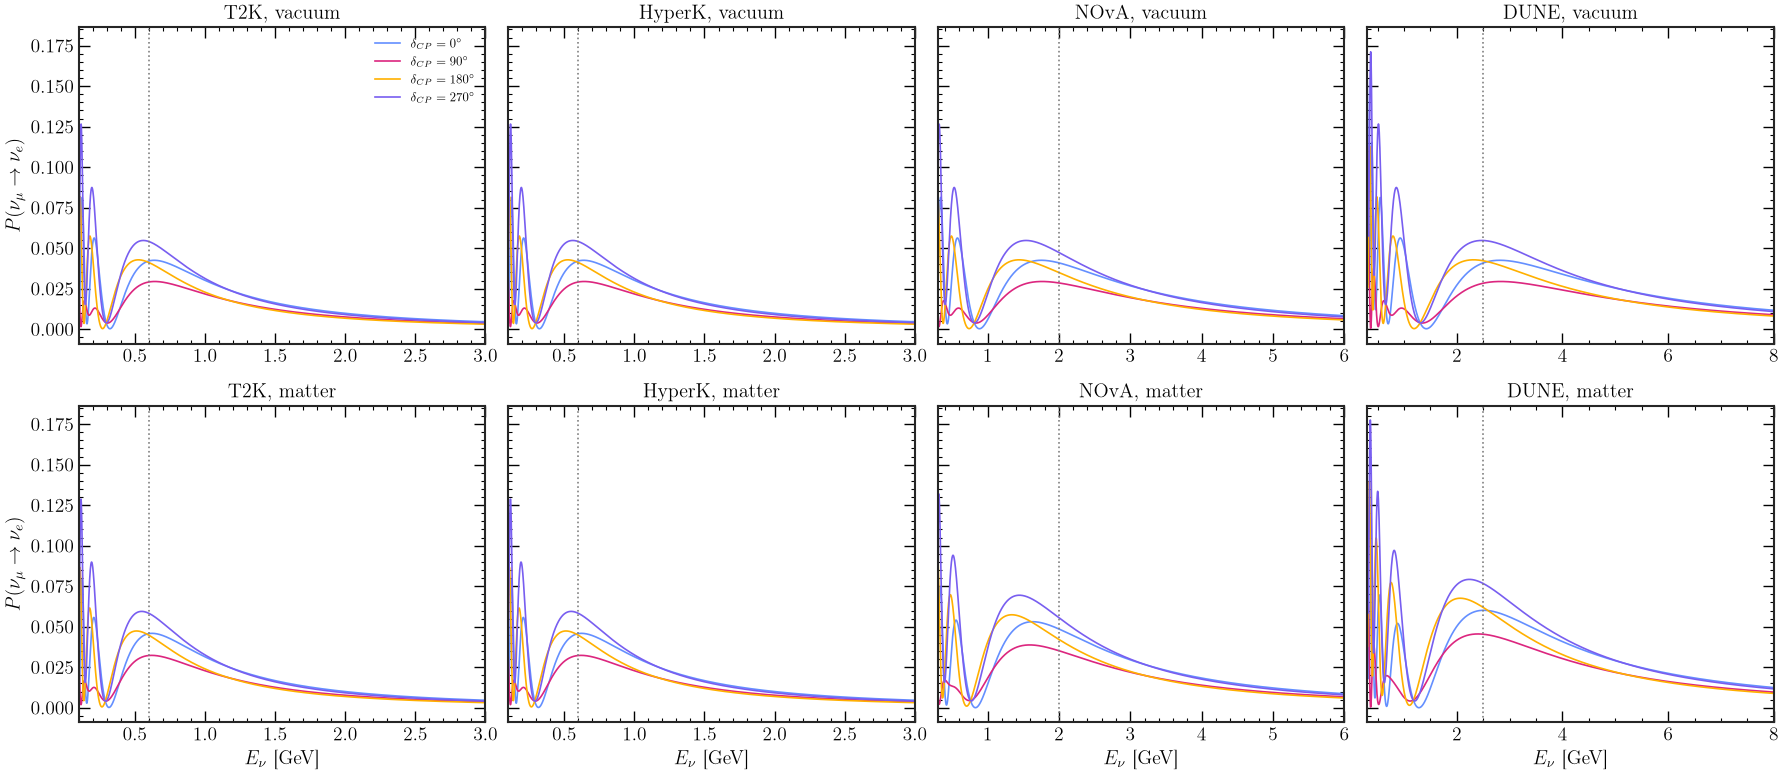

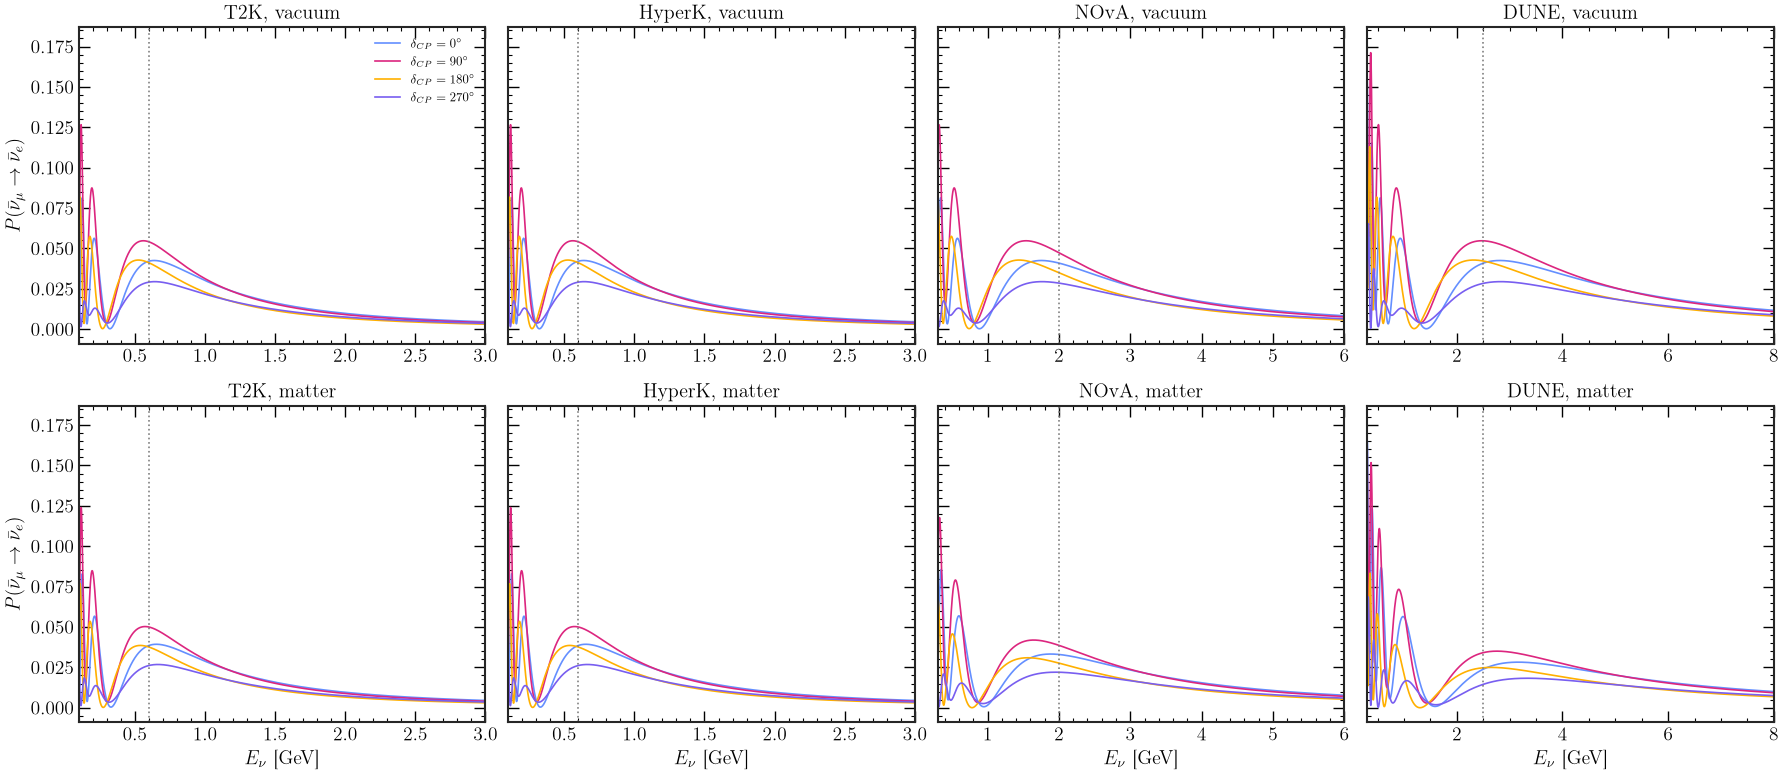

In [10]:
DELTAS = [0, 90, 180, 270]

def plot_delta(a, b, anti=False):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
    for j, name in enumerate(EXPERIMENTS):
        cfg = get_experiment(name)
        for row, matter in enumerate([False, True]):
            ax = axes[row, j]
            for i, d in enumerate(DELTAS):
                osc = NeutrinoOscillator.from_experiment(name, delta_cp=d, antineutrino=anti)
                P = osc.matter(a, b) if matter else osc.vacuum(a, b)
                ax.plot(osc.energy, P, color=c[i], label=rf"$\delta_{{CP}} = {d}^\circ$")
            ax.axvline(cfg["E_peak"], color="gray", ls=":")
            ax.set_xlim(*cfg["E_range"])
            ax.set_title(f"{name}, " + ("matter" if matter else "vacuum"))
            if row == 1:
                ax.set_xlabel(r"$E_\nu$ [GeV]")
            if j == 0:
                ax.set_ylabel(label(a, b, anti))
    axes[0, 0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()

plot_delta("mu", "e")
plot_delta("mu", "e", anti=True)

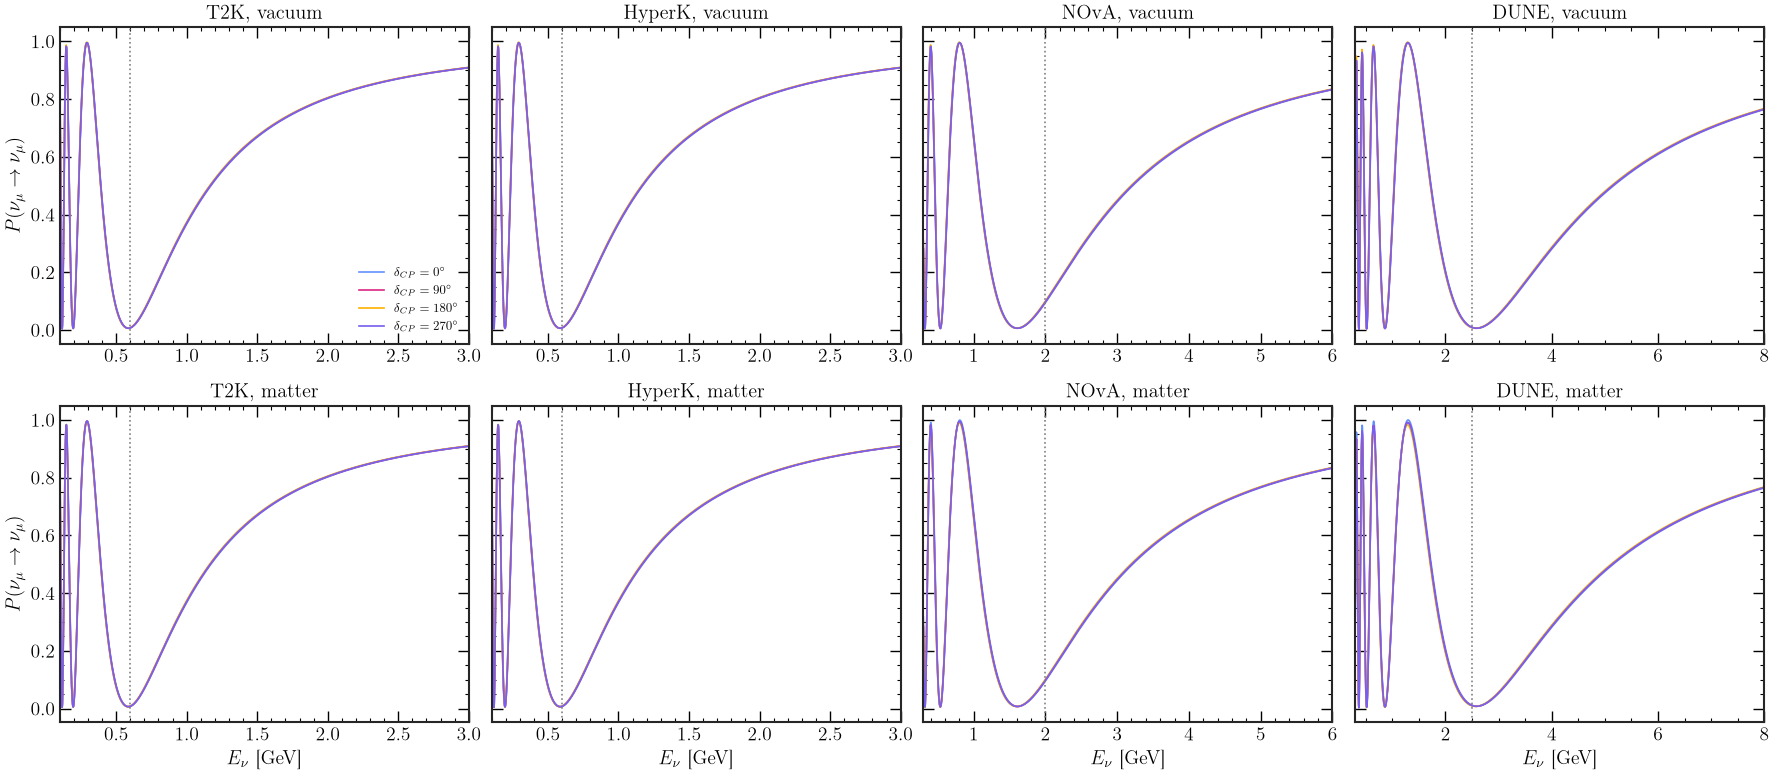

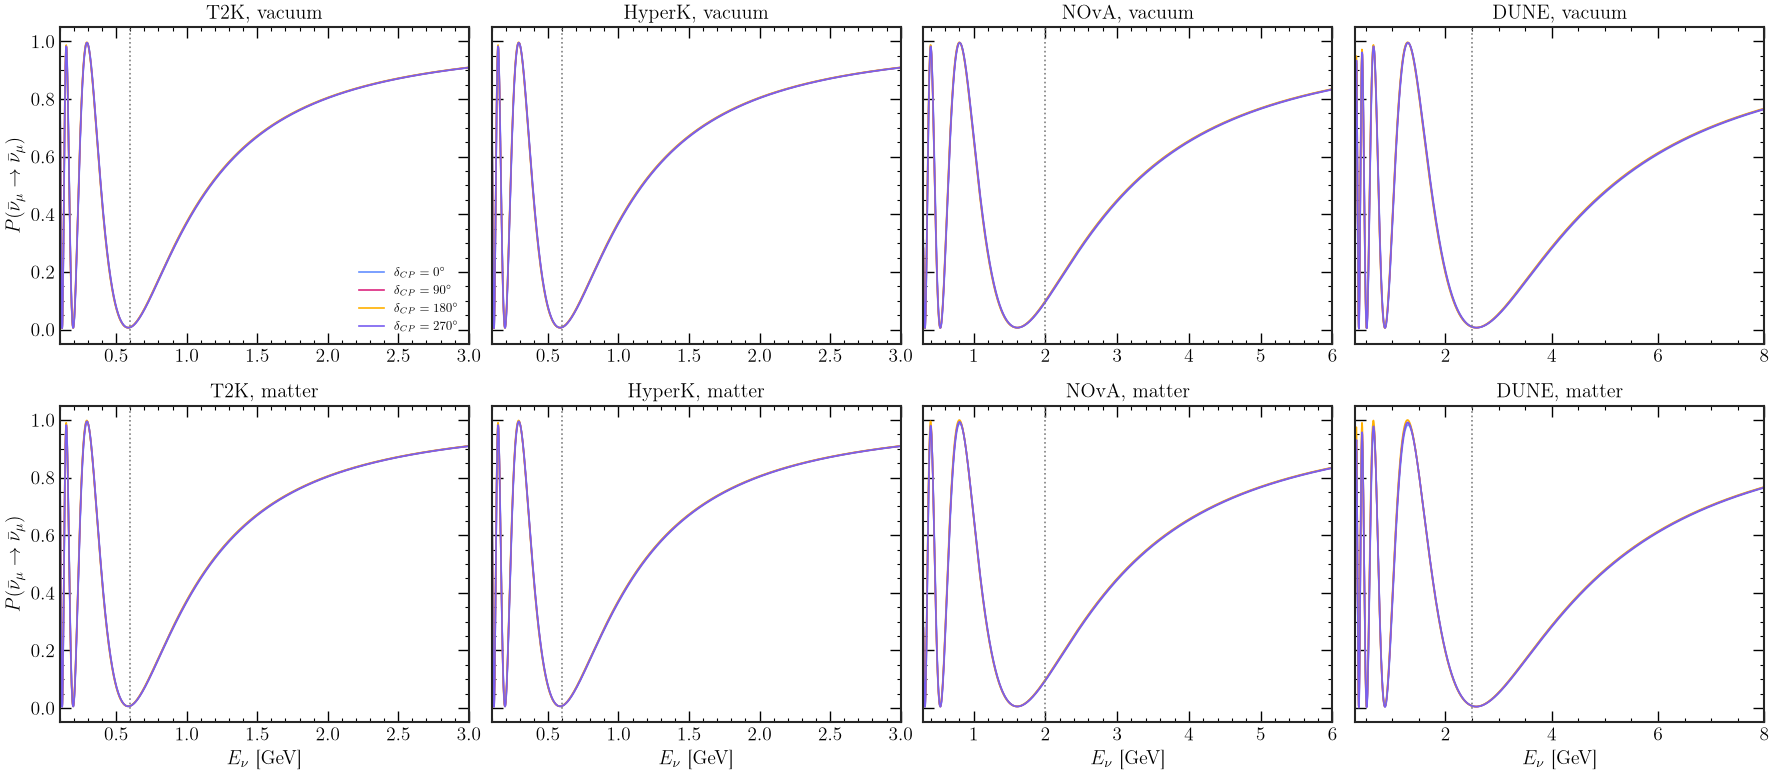

In [11]:
plot_delta("mu", "mu")
plot_delta("mu", "mu", anti=True)

### 2b. Probability vs $\delta_{CP}$ at the typical energy

Solid: matter, dashed: vacuum; blue: $\nu$, magenta: $\bar\nu$ (NO).

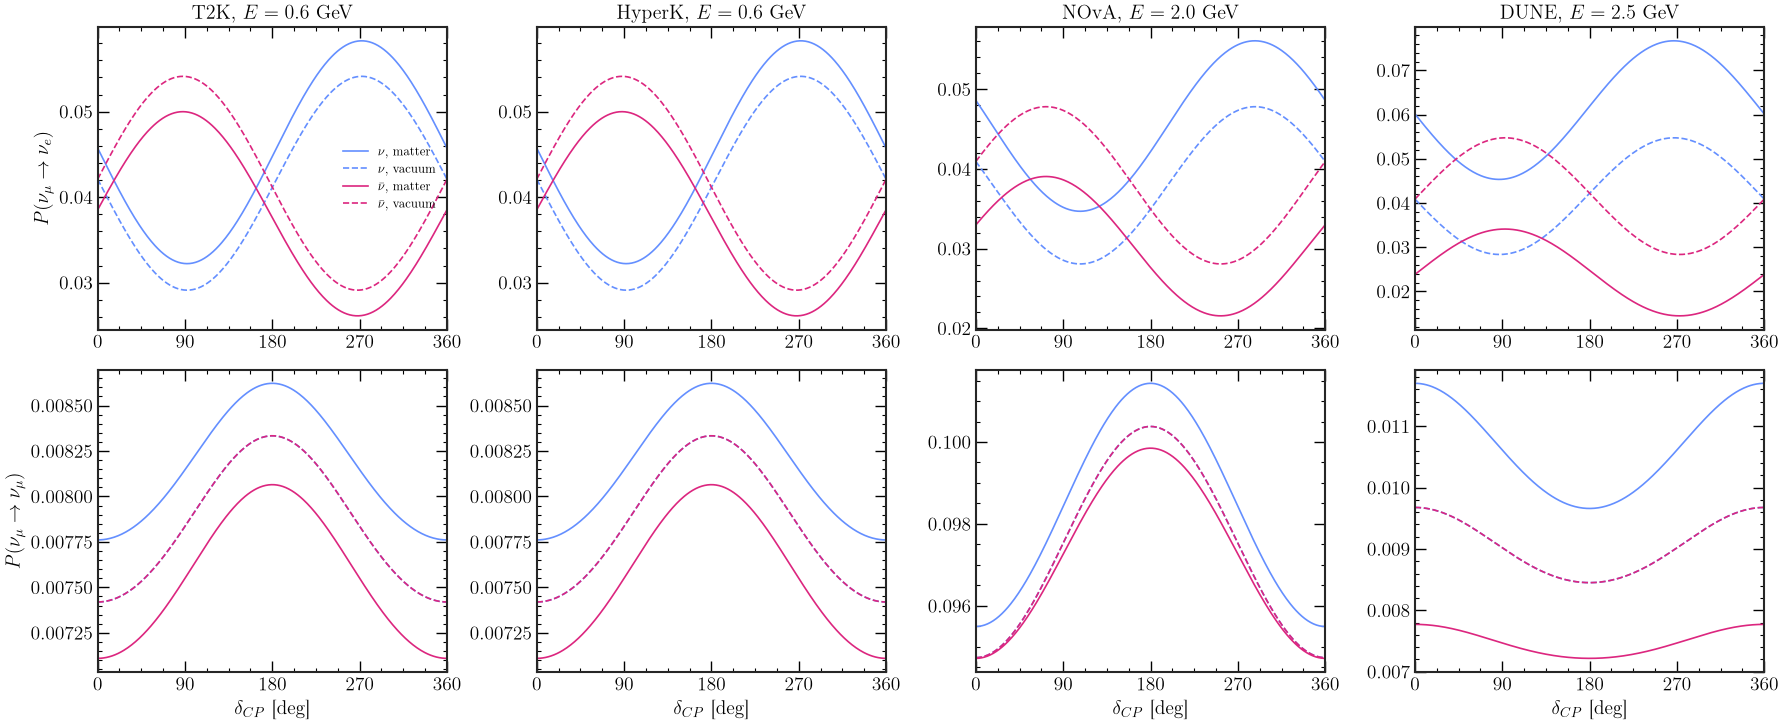

In [12]:
d_scan = np.linspace(0, 360, 361)

fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))
for j, name in enumerate(EXPERIMENTS):
    E0 = get_experiment(name)["E_peak"]
    for row, (a, b) in enumerate([("mu", "e"), ("mu", "mu")]):
        ax = axes[row, j]
        for i, anti in enumerate([False, True]):
            osc = NeutrinoOscillator.from_experiment(name, antineutrino=anti)
            Pm, Pv = [], []
            for d in d_scan:
                osc.set_params(delta_cp=d)
                Pm.append(float(osc.matter(a, b, E=E0)))
                Pv.append(float(osc.vacuum(a, b, E=E0)))
            nu = r"$\bar\nu$" if anti else r"$\nu$"
            ax.plot(d_scan, Pm, color=c[i], label=f"{nu}, matter")
            ax.plot(d_scan, Pv, color=c[i], ls="--", label=f"{nu}, vacuum")
        ax.set_xticks([0, 90, 180, 270, 360])
        ax.set_xlim(0, 360)
        if row == 0:
            ax.set_title(f"{name}, $E = {E0}$ GeV")
        else:
            ax.set_xlabel(r"$\delta_{CP}$ [deg]")
        if j == 0:
            ax.set_ylabel(label(a, b))
axes[0, 0].legend(fontsize=9)
plt.tight_layout()
plt.show()

Symmetry check: does $\delta_{CP}\to 360°-\delta_{CP}$ change the probabilities?

In [16]:
osc = NeutrinoOscillator.from_experiment("DUNE")
for d in [60, 90, 120]:
    for a, b in [("mu", "e"), ("mu", "mu")]:
        osc.set_params(delta_cp=d);        P1 = float(osc.vacuum(a, b, E=2.5))
        osc.set_params(delta_cp=360 - d);  P2 = float(osc.vacuum(a, b, E=2.5))
        print(f"vacuum {a}->{b:3s}  delta = {d:3d}: {P1:.5f}   delta = {360 - d:3d}: {P2:.5f}")
osc.reset()

vacuum mu->e    delta =  60: 0.02981   delta = 300: 0.05263
vacuum mu->mu   delta =  60: 0.00934   delta = 300: 0.00934
vacuum mu->e    delta =  90: 0.02838   delta = 270: 0.05473
vacuum mu->mu   delta =  90: 0.00902   delta = 270: 0.00902
vacuum mu->e    delta = 120: 0.03048   delta = 240: 0.05330
vacuum mu->mu   delta = 120: 0.00872   delta = 240: 0.00872


NeutrinoOscillator(NO, neutrino, L = 1300.0 km, rho = 2.848 g/cm^3)
  sin^2(th12) = 0.3080   (th12 = 33.71 deg)
  sin^2(th13) = 0.02215  (th13 = 8.56 deg)
  sin^2(th23) = 0.4700   (th23 = 43.28 deg)
  delta_CP    = 212.0 deg
  dm2_21      = 7.490e-05 eV^2
  dm2_31      = +2.5130e-03 eV^2
  dm2_32      = +2.4381e-03 eV^2

**What we learn**

* **Appearance $P(\nu_\mu\to\nu_e)$ depends strongly on $\delta_{CP}$**: at the typical energy it changes by
  50–80 % peak-to-peak over the $\delta_{CP}$ range (table in 2c). The effect comes from the interference between the
  "atmospheric" ($\Delta m^2_{31}$) and "solar" ($\Delta m^2_{21}$) amplitudes. At the oscillation maximum this term goes as
  $\sin\delta_{CP}$ and has **opposite sign for $\nu$ and $\bar\nu$**:
  for $\nu$ the maximum is near $\delta_{CP}=270°$ and the minimum near $90°$, for $\bar\nu$ the reverse.
  Away from the maximum a $\cos\delta_{CP}$ part also shifts the peak position in energy.
* $\delta_{CP}$ and $360°-\delta_{CP}$ give **different** appearance probabilities (the $\sin\delta_{CP}$ term changes
  sign): the channel is sensitive to CP violation. In vacuum, $\delta\to-\delta$ for $\nu$ is the same as going to $\bar\nu$.
* **Matter** does not remove the $\delta_{CP}$ dependence; it shifts the curves up or down (up for $\nu$ in NO, down
  for $\bar\nu$) and adds a $\nu/\bar\nu$ difference that is present even for $\delta_{CP}=0$. At DUNE this shift is as
  large as the $\delta_{CP}$ effect, which is why the ordering and $\delta_{CP}$ have to be measured together.
* **Disappearance $P(\nu_\mu\to\nu_\mu)$** changes by only $\sim 0.001$–$0.002$ in absolute terms at T2K, Hyper-K and
  DUNE, where the typical energy sits at the bottom of the dip ($P\approx 0.01$): the *relative* numbers in 2c look
  sizeable (5–20 %) only because $P$ is almost zero. At NOvA ($P\approx0.1$, on the flank of the dip) it is
  $\sim 0.006$, i.e. 6 %. The change is small and is degenerate with small changes of $\theta_{23}$ and $\Delta m^2_{32}$.
  It enters only through $\cos\delta_{CP}$: $\delta_{CP}$ and $360°-\delta_{CP}$ give the same result, and in vacuum
  $\nu$ and $\bar\nu$ are identical (the dashed curves overlap in 2b). It cannot see CP violation; it measures
  $|\Delta m^2_{32}|$ and $\sin^2 2\theta_{23}$.
* In vacuum, $\bar\nu$ at $\delta_{CP}$ is exactly $\nu$ at $360°-\delta_{CP}$ (compare the $90°$ and $270°$ curves of
  the $\nu$ and $\bar\nu$ figures in 2a), and $\delta_{CP}=0°, 180°$ give $\nu = \bar\nu$.